### RNN, LSTM, Seq2Seq의 한계
RNN은 MLP의 순서 고려 불가를 해결하기 위해 등장 -> "단어를 순서대로 넣으며 이전까지의 결과를 기억해두자"

#### 1. RNN의 구조
- 수식
$$ h_1 = tanh(w_h h_{t-1} + w_x x_t + b) $$
    - $x_t$ : $t$번째 시점의 입력
    - $h_{t-1}$ : 이전 시점까지의 입력
    - $w_h, w_x$ : 모든 시점에서 공유되는 가중치 행렬
    - $tanh$ : 활성화 함수 - 출력을 (-1, 1) 사이로 고정해 값이 폭주하는 것을 억제

- 구조
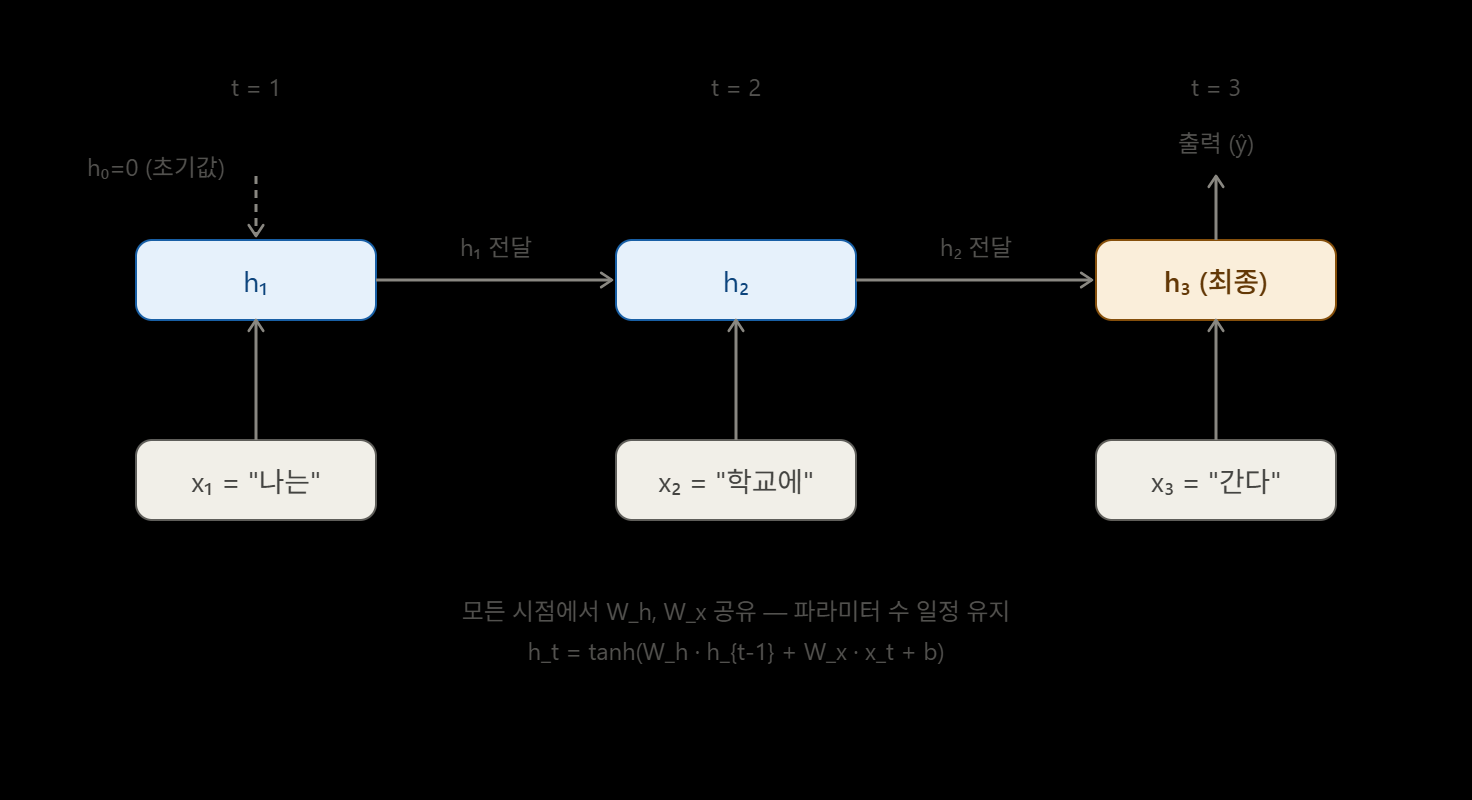
    - 각 시점의 $h_t$가 다음 시점으로 전달되면서 기억이 누적됨
    - 각 단계의 셀은 동일한 가중치를 사용하는 같은 함수 <br> - 단지 입력($x_t$)와 기억($h_{t-1}$)만 다름

#### 2. RNN의 한계
##### (1) **기울기 소실**
RNN의 역전파는 시간을 거슬러 가야 함 (BPTT; BackPropagation Through Time) <br>
$t=3$에서 발생한 손실이 $t=1$의 가중치에 미치는 영향을 구하면: <br>
$\frac{\partial L}{\partial {w_x}} |_{t-1} \propto \frac{\partial {h_3}}{\partial {h_2}} \cdot \frac{\partial {h_2}}{\partial {h_1}} \cdot \frac{\partial {h_1}}{\partial {w_x}}$

각 $\frac{\partial {h_t}}{\partial {h_{t-1}}}$항은 $w_h \cdot tanh'(z_t)$를 포함.
$tanh'$의 최댓값은 1이고 보통 1보다 작은 값 도출 -> 반복해 곱해지면 0에 점차 수렴하게 됨 <br>
= 문장이 길수록 앞쪽 시점의 기울기가 0에 가까워짐 <br>
= "먼 과거"의 단어는 학습이 안됨

##### (2) 정보 병목
문장 전체의 의미를 고정 크기 벡터 $h_T$에 압축해야 함 <br>
100 단어의 문장이라면 모든 정보를 $h_100$에 담아야 하는데, 새로운 정보가 누적되며 앞쪽 정보는 희석됨.

#### 3. LSTM
RNN의 기울기 소실 문제를 해결하기 위해 고안됨 <br>
"별도의 장기 기억 통로(Cell State)를 만들어 기울기가 사라지지 않고 흐를 수 있는 경로를 확보"

##### (1) 핵심 구성요소: 3개의 gate
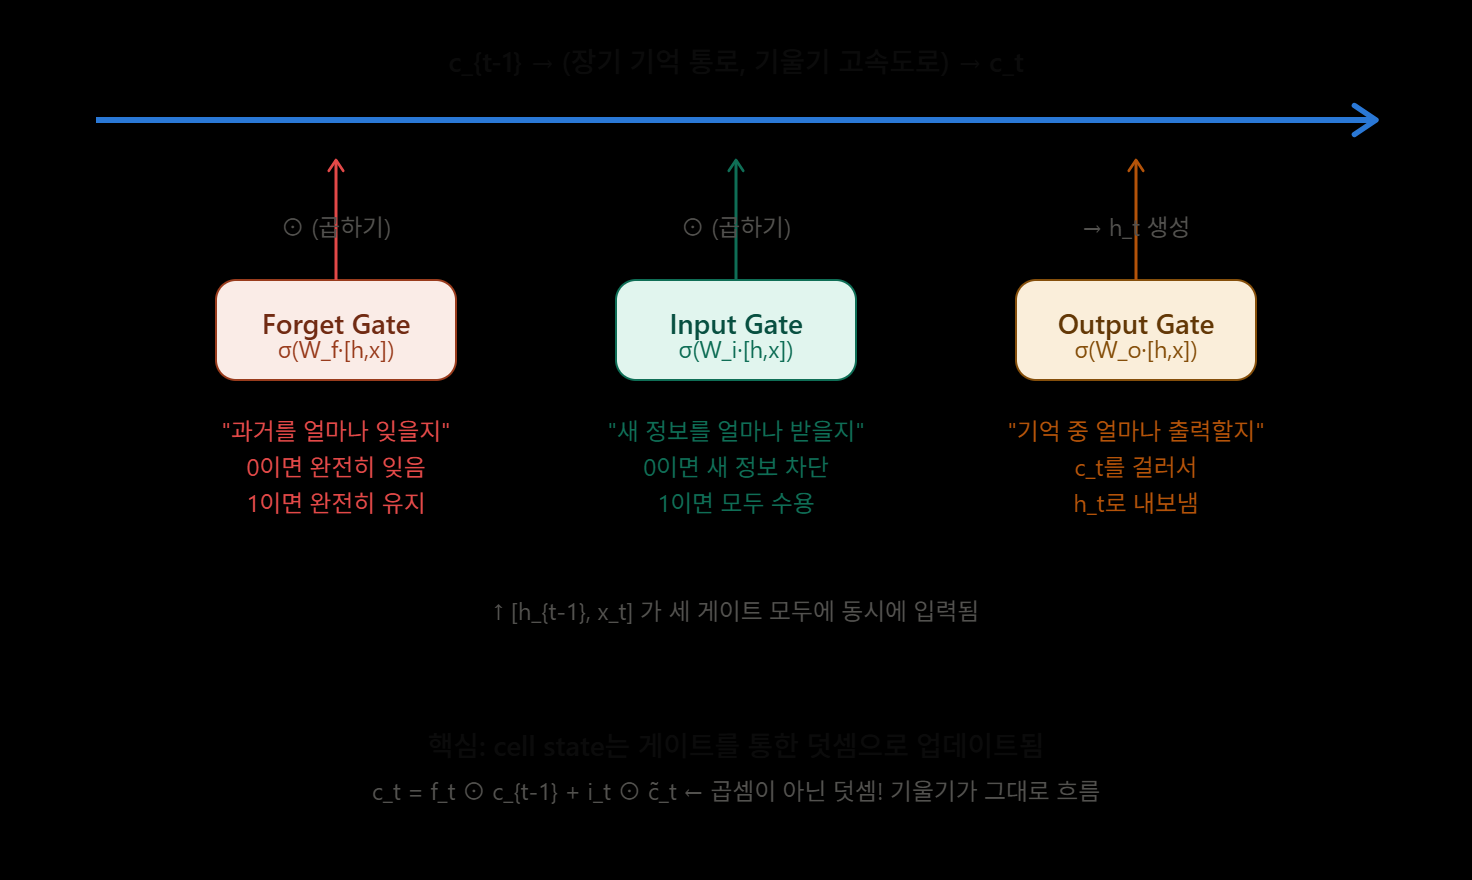
gate를 통해 얼마나 통과시킬지 결정. Sigmoid를 이용해 0 -> 차단 / 1 -> 통과
- Forget Gate
$$f_t = \sigma(w_f \cdot [h_{t-1}, x_t] + b_f)$$

- Input Gate
$$i_t = \sigma(w_i \cdot [h_{t-1}, x_t] + b_i)$$

- Output Gate
$$o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$$

+ Cell State <br>
    - $ \tilde{C}_t = \tanh(W_c \cdot [h_{t-1}, x_t] + b_c) $ - 현 시점에서 추가할 후보 기억
    - $ C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t $ - Cell State 업데이트
    - $ h_t = o_t \odot tanh(C_t) $

    **LSTM이 기울기 소실을 완화할 수 있는 핵심 이유** <br>
    $C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t $ <br>
    - +가 핵심!
        - 역전파 시 $\frac{\partial {C_t}}{\partial {c_{t-1}}} = f_t$
        - $f_t$ : 학습으로 조절 가능한 값으로, 기울기가 필요한 구간에서 $f_t \approx 1$로 유지해 기울기가 소실 없이 그대로 흐름
    - 하지만 완벽한 해결책은 아님.
        - 여전히 순차 처리로 인해 병렬화 불가
        - 매우 긴 시퀀스에서는 $f_t$가 누적 곱돼 소실 가능성 존재
        - 정보 병목 문제는 그대로

In [7]:
# 기울기 소실 확인

import numpy as np
import urllib.request

#  데이터 로드
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = urllib.request.urlopen(url).read().decode('utf-8')[:3000]   # 앞 3000자만 사용

chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_idx = {c:i for i,c in enumerate(chars)}
data = [char_to_idx[c] for c in text]
print(f"텍스트 길이: {len(text)}, 고유 문자 수: {vocab_size}")

hidden_size = 32
np.random.seed(1)
Wx = np.random.randn(hidden_size, vocab_size) * 0.01
Wh = np.random.randn(hidden_size, hidden_size) * 0.01
bh = np.zeros((hidden_size,1))

def one_hot(idx):
    v = np.zeros((vocab_size,1)); v[idx]=1; return v

# Part A. 기울기 소실을 숫자로 직접 확인
#   ∂h_T/∂h_t = ∏ diag(1-h_s²)·Wₕ  (같은 항을 시점 수만큼 반복해서 곱함)
T = 40
h = np.zeros((hidden_size,1))
hs = [h]
for t in range(T):
    h = np.tanh(Wx @ one_hot(data[t]) + Wh @ h + bh)
    hs.append(h)

J = np.eye(hidden_size)
print("\n=== ∂h_T/∂h_t 크기 (T=40, t를 과거로 이동) ===")
for k in range(1, T+1):
    s = T - k + 1
    D = np.diag((1 - hs[s].flatten()**2))
    J = D @ Wh @ J
    if k in [1,5,10,20,40]:
        print(f"  {k:2d}시점 전까지의 누적 기울기 크기: {np.linalg.norm(J):.10f}")


# Part B. 짧은 시퀀스로 실제 학습 (loss 감소 확인)

np.random.seed(2)
Wx = np.random.randn(hidden_size, vocab_size) * 0.01
Wh = np.random.randn(hidden_size, hidden_size) * 0.01
Wy = np.random.randn(vocab_size, hidden_size) * 0.01
bh = np.zeros((hidden_size,1)); by = np.zeros((vocab_size,1))
mem = [np.zeros_like(p) for p in [Wx,Wh,Wy,bh,by]]   # Adagrad 누적용

def step_fn(inputs, targets, h_prev):
    xs,hs,ps = {}, {}, {}
    hs[-1] = np.copy(h_prev)
    loss = 0
    for t in range(len(inputs)):
        xs[t] = one_hot(inputs[t])
        hs[t] = np.tanh(Wx @ xs[t] + Wh @ hs[t-1] + bh)
        y = Wy @ hs[t] + by
        ps[t] = np.exp(y-np.max(y)) / np.sum(np.exp(y-np.max(y)))
        loss += -np.log(ps[t][targets[t],0] + 1e-9)
    dWx, dWh, dWy = np.zeros_like(Wx), np.zeros_like(Wh), np.zeros_like(Wy)
    dbh, dby = np.zeros_like(bh), np.zeros_like(by)
    dh_next = np.zeros_like(hs[0])
    for t in reversed(range(len(inputs))):
        dy = np.copy(ps[t]); dy[targets[t]] -= 1
        dWy += dy @ hs[t].T; dby += dy
        dh = Wy.T @ dy + dh_next
        dh_raw = (1 - hs[t]**2) * dh
        dbh += dh_raw
        dWx += dh_raw @ xs[t].T
        dWh += dh_raw @ hs[t-1].T
        dh_next = Wh.T @ dh_raw
    for dparam in [dWx,dWh,dWy,dbh,dby]:
        np.clip(dparam, -5, 5, out=dparam)
    return loss/len(inputs), (dWx,dWh,dWy,dbh,dby), hs[len(inputs)-1]

seq_len = 10   # Part A에서 10시점 넘어가면 기울기가 죽는 걸 확인했으므로 짧게 설정
lr = 0.1
h_prev = np.zeros((hidden_size,1))
params = [Wx,Wh,Wy,bh,by]
losses = []

print("\n=== Part B: 학습 진행 (loss) ===")
for step in range(3000):
    p = (step*seq_len) % (len(data)-seq_len-1)
    if p < seq_len: h_prev = np.zeros((hidden_size,1))
    inputs = data[p:p+seq_len]; targets = data[p+1:p+seq_len+1]
    loss, grads, h_prev = step_fn(inputs, targets, h_prev)
    for param, dparam, m in zip(params, grads, mem):
        m += dparam*dparam
        param += -lr * dparam / np.sqrt(m + 1e-8)   # Adagrad
    losses.append(loss)
    if step % 500 == 0:
        print(f"step {step:4d} | loss={np.mean(losses[-100:]):.3f}")

print(f"\n최종 loss: {np.mean(losses[-100:]):.3f} (랜덤 베이스라인: {np.log(vocab_size):.3f})")

텍스트 길이: 3000, 고유 문자 수: 52

=== ∂h_T/∂h_t 크기 (T=40, t를 과거로 이동) ===
   1시점 전까지의 누적 기울기 크기: 0.3212403101
   5시점 전까지의 누적 기울기 크기: 0.0000029055
  10시점 전까지의 누적 기울기 크기: 0.0000000000
  20시점 전까지의 누적 기울기 크기: 0.0000000000
  40시점 전까지의 누적 기울기 크기: 0.0000000000

=== Part B: 학습 진행 (loss) ===
step    0 | loss=3.951
step  500 | loss=2.377
step 1000 | loss=2.143
step 1500 | loss=2.050
step 2000 | loss=1.922
step 2500 | loss=1.832

최종 loss: 1.733 (랜덤 베이스라인: 3.951)


#### 4. Seq2Seq - RNN / LSTM을 번역에 적용
Seq2Seq : RNN 또는 LSTM을 두 개(인코더 + 디코더) 연결해 기계 번역 같은 "입력 시퀀스 -> 출력 시퀀스" 문제를 푸는 구조

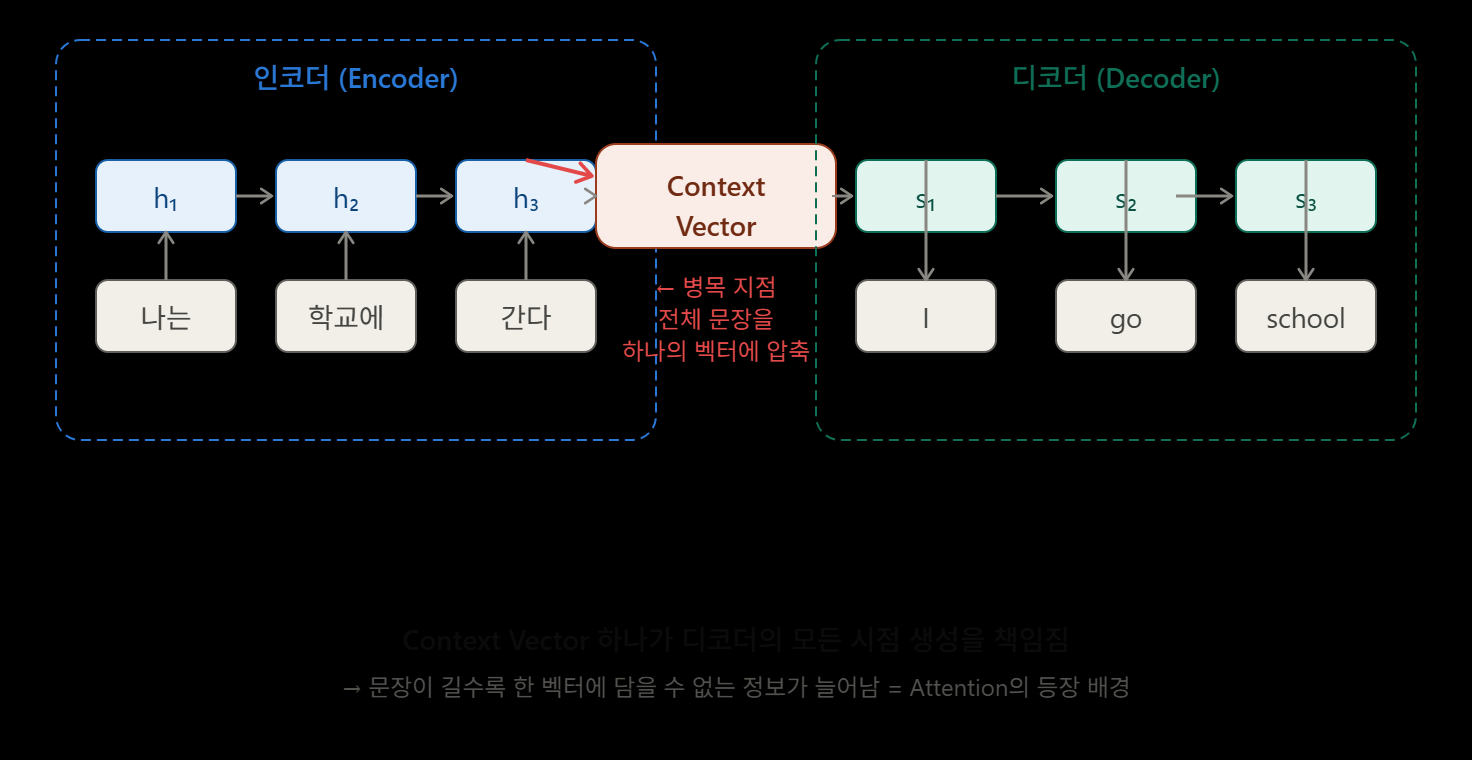
- 작동 방식
    - (1) 인코더가 입력 문장을 순서대로 처리해 마지막 은닉 상태를 Context Vector로 만듦
    - (2) 디코더가 이 Context Vector를 출발점으로 삼아 출력 단어를 하나씩 생성

**왜 LSTM을 사용하더라도 구조적 병목은 그대로일까?** <br>
: LSTM이든 RNN이든 $C=h_3$이라는 고정 크기 벡터 하나 -> "모든 입력 정보를 한 벡터에 압축해야 한다"는 한계가 존재 <br>
ex) 통로가 1차선인 도로 -> 통로 폭을 넓히자! (Attention의 등장 배경, decoder가 c 하나가 아닌 $h_1, h_2, h_3 ..$ 전체에 직접 접근하는 방식)

In [8]:
import numpy as np
import urllib.request

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = urllib.request.urlopen(url).read().decode('utf-8')[:3000]
chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_idx = {c:i for i,c in enumerate(chars)}
data = [char_to_idx[c] for c in text]

def one_hot(idx):
    v = np.zeros((vocab_size,1)); v[idx]=1; return v

hidden_size = 32
enc_len, dec_len = 10, 10

np.random.seed(3)
# ── 인코더 파라미터 (입력을 읽는 역할) ──
Wxe = np.random.randn(hidden_size, vocab_size) * 0.01
Whe = np.random.randn(hidden_size, hidden_size) * 0.01
bhe = np.zeros((hidden_size,1))
# ── 디코더 파라미터 (인코더와 완전히 분리된 별도 가중치, 출력을 생성하는 역할) ──
Wxd = np.random.randn(hidden_size, vocab_size) * 0.01
Whd = np.random.randn(hidden_size, hidden_size) * 0.01
bhd = np.zeros((hidden_size,1))
Wy  = np.random.randn(vocab_size, hidden_size) * 0.01
by  = np.zeros((vocab_size,1))

params = [Wxe,Whe,bhe,Wxd,Whd,bhd,Wy,by]
mem = [np.zeros_like(p) for p in params]

def forward_backward(enc_input, dec_target):
    # ── 인코더: 입력을 끝까지 읽음 ──
    he = {-1: np.zeros((hidden_size,1))}
    xe = {}
    for t in range(enc_len):
        xe[t] = one_hot(enc_input[t])
        he[t] = np.tanh(Wxe @ xe[t] + Whe @ he[t-1] + bhe)
    context = he[enc_len-1]          # ★ 입력 10글자 전체가 이 벡터 하나로 압축됨

    # ── 디코더: context를 초기 hidden state로 받아서 시작 (teacher forcing) ──
    hd = {-1: context}
    xd, ps = {}, {}
    dec_input_seq = [char_to_idx['\n']] + dec_target[:-1]   # 이전 정답 글자를 다음 입력으로
    loss = 0
    for t in range(dec_len):
        xd[t] = one_hot(dec_input_seq[t])
        hd[t] = np.tanh(Wxd @ xd[t] + Whd @ hd[t-1] + bhd)  # context 정보가 여기서부터 계속 흘러감
        y = Wy @ hd[t] + by
        ps[t] = np.exp(y-np.max(y)) / np.sum(np.exp(y-np.max(y)))
        loss += -np.log(ps[t][dec_target[t],0] + 1e-9)

    # ── 역전파: 디코더 → context → 인코더 순서로 거슬러 감 ──
    grads = {n: np.zeros_like(p) for n,p in zip(
        ['Wxe','Whe','bhe','Wxd','Whd','bhd','Wy','by'], params)}
    dh_next_dec = np.zeros((hidden_size,1))
    for t in reversed(range(dec_len)):
        dy = np.copy(ps[t]); dy[dec_target[t]] -= 1
        grads['Wy'] += dy @ hd[t].T
        grads['by'] += dy
        dh = Wy.T @ dy + dh_next_dec
        dh_raw = (1 - hd[t]**2) * dh
        grads['bhd'] += dh_raw
        grads['Wxd'] += dh_raw @ xd[t].T
        grads['Whd'] += dh_raw @ hd[t-1].T
        dh_next_dec = Whd.T @ dh_raw

    d_context = dh_next_dec          # ★ 병목 지점: 모든 디코더 정보가 이 벡터 하나를 통해서만 인코더로 전달됨
    dh_next_enc = d_context
    for t in reversed(range(enc_len)):
        dh_raw = (1 - he[t]**2) * dh_next_enc
        grads['bhe'] += dh_raw
        grads['Wxe'] += dh_raw @ xe[t].T
        grads['Whe'] += dh_raw @ he[t-1].T
        dh_next_enc = Whe.T @ dh_raw

    for g in grads.values():
        np.clip(g, -5, 5, out=g)
    return loss/dec_len, [grads[n] for n in ['Wxe','Whe','bhe','Wxd','Whd','bhd','Wy','by']]

losses = []
for step in range(4000):
    p = np.random.randint(0, len(data)-enc_len-dec_len-1)
    enc_input = data[p:p+enc_len]
    dec_target = data[p+enc_len:p+enc_len+dec_len]
    loss, grads = forward_backward(enc_input, dec_target)
    for i in range(len(params)):
        mem[i] += grads[i]**2
        params[i] += -0.1 * grads[i] / np.sqrt(mem[i]+1e-8)   # Adagrad
    losses.append(loss)
    if step % 800 == 0:
        print(f"step {step:4d} | loss={np.mean(losses[-100:]):.3f}")

step    0 | loss=3.951
step  800 | loss=2.536
step 1600 | loss=2.281
step 2400 | loss=2.059
step 3200 | loss=2.093


In [10]:
## PyTorch로 구현

import torch
import torch.nn as nn
import numpy as np
import urllib.request

url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
text = urllib.request.urlopen(url).read().decode('utf-8')[:3000]
chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_idx = {c:i for i,c in enumerate(chars)}
data = [char_to_idx[c] for c in text]

hidden_size = 32
enc_len, dec_len = 10, 10
torch.manual_seed(3)

class Seq2Seq(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        # 인코더: 입력을 끝까지 읽고 마지막 hidden state를 반환
        self.encoder = nn.RNN(vocab_size, hidden_size, batch_first=True)
        # 디코더: 인코더의 마지막 hidden state를 "초기 상태"로 받음
        self.decoder = nn.RNN(vocab_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)   # hidden → vocab 크기 logit

    def forward(self, enc_input, dec_input):
        # enc_input: (batch, enc_len, vocab_size) one-hot
        _, context = self.encoder(enc_input)           # context: (1,batch,hidden) ★병목 지점
        dec_out, _ = self.decoder(dec_input, context)   # context를 디코더 초기 hidden으로 사용
        logits = self.fc(dec_out)                       # (batch, dec_len, vocab_size)
        return logits

model = Seq2Seq(vocab_size, hidden_size)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

def make_batch(batch_size):
    enc_in, dec_in, dec_tgt = [], [], []
    for _ in range(batch_size):
        p = np.random.randint(0, len(data)-enc_len-dec_len-1)
        enc_idx = data[p:p+enc_len]
        tgt_idx = data[p+enc_len:p+enc_len+dec_len]
        dec_input_idx = [char_to_idx['\n']] + tgt_idx[:-1]    # teacher forcing 입력
        enc_in.append(enc_idx); dec_in.append(dec_input_idx); dec_tgt.append(tgt_idx)
    enc_in = torch.nn.functional.one_hot(torch.tensor(enc_in), vocab_size).float()
    dec_in = torch.nn.functional.one_hot(torch.tensor(dec_in), vocab_size).float()
    dec_tgt = torch.tensor(dec_tgt)
    return enc_in, dec_in, dec_tgt

losses = []
for step in range(1500):
    enc_in, dec_in, dec_tgt = make_batch(32)
    logits = model(enc_in, dec_in)                        # (32,10,vocab)
    loss = loss_fn(logits.reshape(-1, vocab_size), dec_tgt.reshape(-1))

    optimizer.zero_grad()
    loss.backward()          # ★ 디코더→context→인코더로 이어지는 역전파가 여기서 자동 수행
    optimizer.step()

    losses.append(loss.item())
    if step % 300 == 0:
        print(f"step {step:4d} | loss={np.mean(losses[-50:]):.3f}")

print(f"최종 loss: {np.mean(losses[-50:]):.3f} (랜덤 베이스라인: {np.log(vocab_size):.3f})")

step    0 | loss=3.960
step  300 | loss=1.778
step  600 | loss=1.489
step  900 | loss=1.347
step 1200 | loss=1.271
최종 loss: 1.179 (랜덤 베이스라인: 3.951)
